# Telco Customer Churn Analysis

# Imports

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Cleaning
## Understanding the data

### First 5 Rows

In [173]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head() #First 5 rows of the dataset

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Information

In [174]:
df.info() #Information about the dataset

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

The TotalCharges column seems to be a str type rather than a float which will require some reformatting

### Data description

In [175]:
df.describe() #Statistical summary of the dataset

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Since TotalCharges is non-numeric then we cannot see it on the summary

### Null entries

In [176]:
df.isnull().sum() #Check for missing values in the dataset per column

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No null values detected

## Data Cleaning

### Formating TotalCharges

In [177]:
print(df['TotalCharges'].unique()[:20])
print(df['TotalCharges'].value_counts().head(20)) #

#I'm using these 2 lines to show

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str
TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
20.25     6
20.45     5
20.3      5
74.7      4
70.6      4
44        4
75.3      4
20.4      4
19.85     4
49.9      4
Name: count, dtype: int64


The data frame seems to contain empty srtings which need to be handled

In [178]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Calculate missing values using tenure * MonthlyCharges
df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

# #Here is the new dataset information after cleaning TotalCharges column

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Incosistent categories

In [179]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("------")

customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
------
gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
------
SeniorCitizen
[0 1]
------
Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
------
Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
------
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
------
PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
------
MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
------
InternetService
<StringArr

I'll map 0 to 'No' and 1 to 'Yes' in SeniorCitizen column for better readability

In [180]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}) 

# Churn Analysis

## Overall Churn Rate

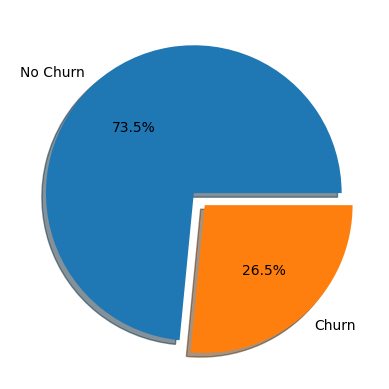

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


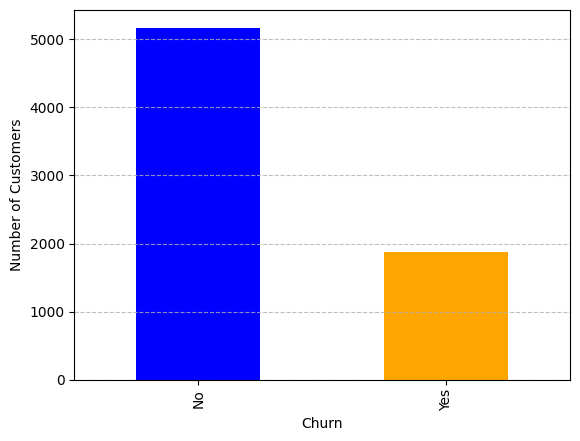

In [202]:
churn_rate = df['Churn'].value_counts(normalize=True) 

plt.pie(churn_rate*100, 
        labels=['No Churn', 'Churn'], 
        explode=(0.01,0.1), shadow=True, 
        autopct='%1.1f%%') #autopct adds percentage labels to the pie chart

plt.show()
print(churn_rate)


df['Churn'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.grid(True, axis='y', linestyle='--', alpha=0.8, which='both', zorder=0) 
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()